In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [4]:
data=pd.read_csv('data.csv', delimiter=',', encoding="ISO-8859-1")
data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [8]:
data.describe(exclude=['int64','float64']).T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/2011 14:41,1114
Country,541909,38,United Kingdom,495478


In [9]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
data.dropna(inplace=True)

In [11]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
data[data['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [14]:
data[data['UnitPrice']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [16]:
data[data['UnitPrice']<0].shape[0]

0

In [17]:
data.drop(data[data['Quantity']<0].index, inplace=True)

In [18]:
data.shape

(397924, 8)

## calculating how much each customer is spending

In [20]:
data['Total_Sales']=data['Quantity']*data['UnitPrice']
new_data=data.groupby('CustomerID')['Total_Sales'].sum().reset_index()
new_data

,CustomerID,Total_Sales
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4334,18280.0,180.60
4335,18281.0,80.82
4336,18282.0,178.05
4337,18283.0,2094.88


## calculating how many transactions each customer is doing

In [21]:
num_trans=data.groupby('CustomerID')['InvoiceNo'].count().reset_index()
num_trans

,CustomerID,InvoiceNo
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17
...,...,...
4334,18280.0,10
4335,18281.0,7
4336,18282.0,12
4337,18283.0,756


## calculating last transaction of each cutomer

In [22]:
data['InvoiceDate']=pd.to_datetime(data['InvoiceDate'])

In [23]:
data['Last Transaction']=(data['InvoiceDate'].max()-data['InvoiceDate']).dt.days

In [24]:
data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Sales,Last Transaction
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,373
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,373
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,373
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,373
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,373


In [25]:
lt=data.groupby(['CustomerID','Country'])['Last Transaction'].max().reset_index()

In [26]:
lt

,CustomerID,Country,Last Transaction
0,12346.0,United Kingdom,325
1,12347.0,Iceland,366
2,12348.0,Finland,357
3,12349.0,Italy,18
4,12350.0,Norway,309
...,...,...,...
4342,18280.0,United Kingdom,277
4343,18281.0,United Kingdom,180
4344,18282.0,United Kingdom,125
4345,18283.0,United Kingdom,336


In [27]:
type(lt)

pandas.core.frame.DataFrame

In [28]:
merge_table=pd.merge(lt,num_trans,how='inner',on='CustomerID')
new_df=pd.merge(merge_table,new_data,how='inner', on='CustomerID')
new_df

,CustomerID,Country,Last Transaction,InvoiceNo,Total_Sales
0,12346.0,United Kingdom,325,1,77183.60
1,12347.0,Iceland,366,182,4310.00
2,12348.0,Finland,357,31,1797.24
3,12349.0,Italy,18,73,1757.55
4,12350.0,Norway,309,17,334.40
...,...,...,...,...,...
4342,18280.0,United Kingdom,277,10,180.60
4343,18281.0,United Kingdom,180,7,80.82
4344,18282.0,United Kingdom,125,12,178.05
4345,18283.0,United Kingdom,336,756,2094.88


## Removal of outliers using boxplot

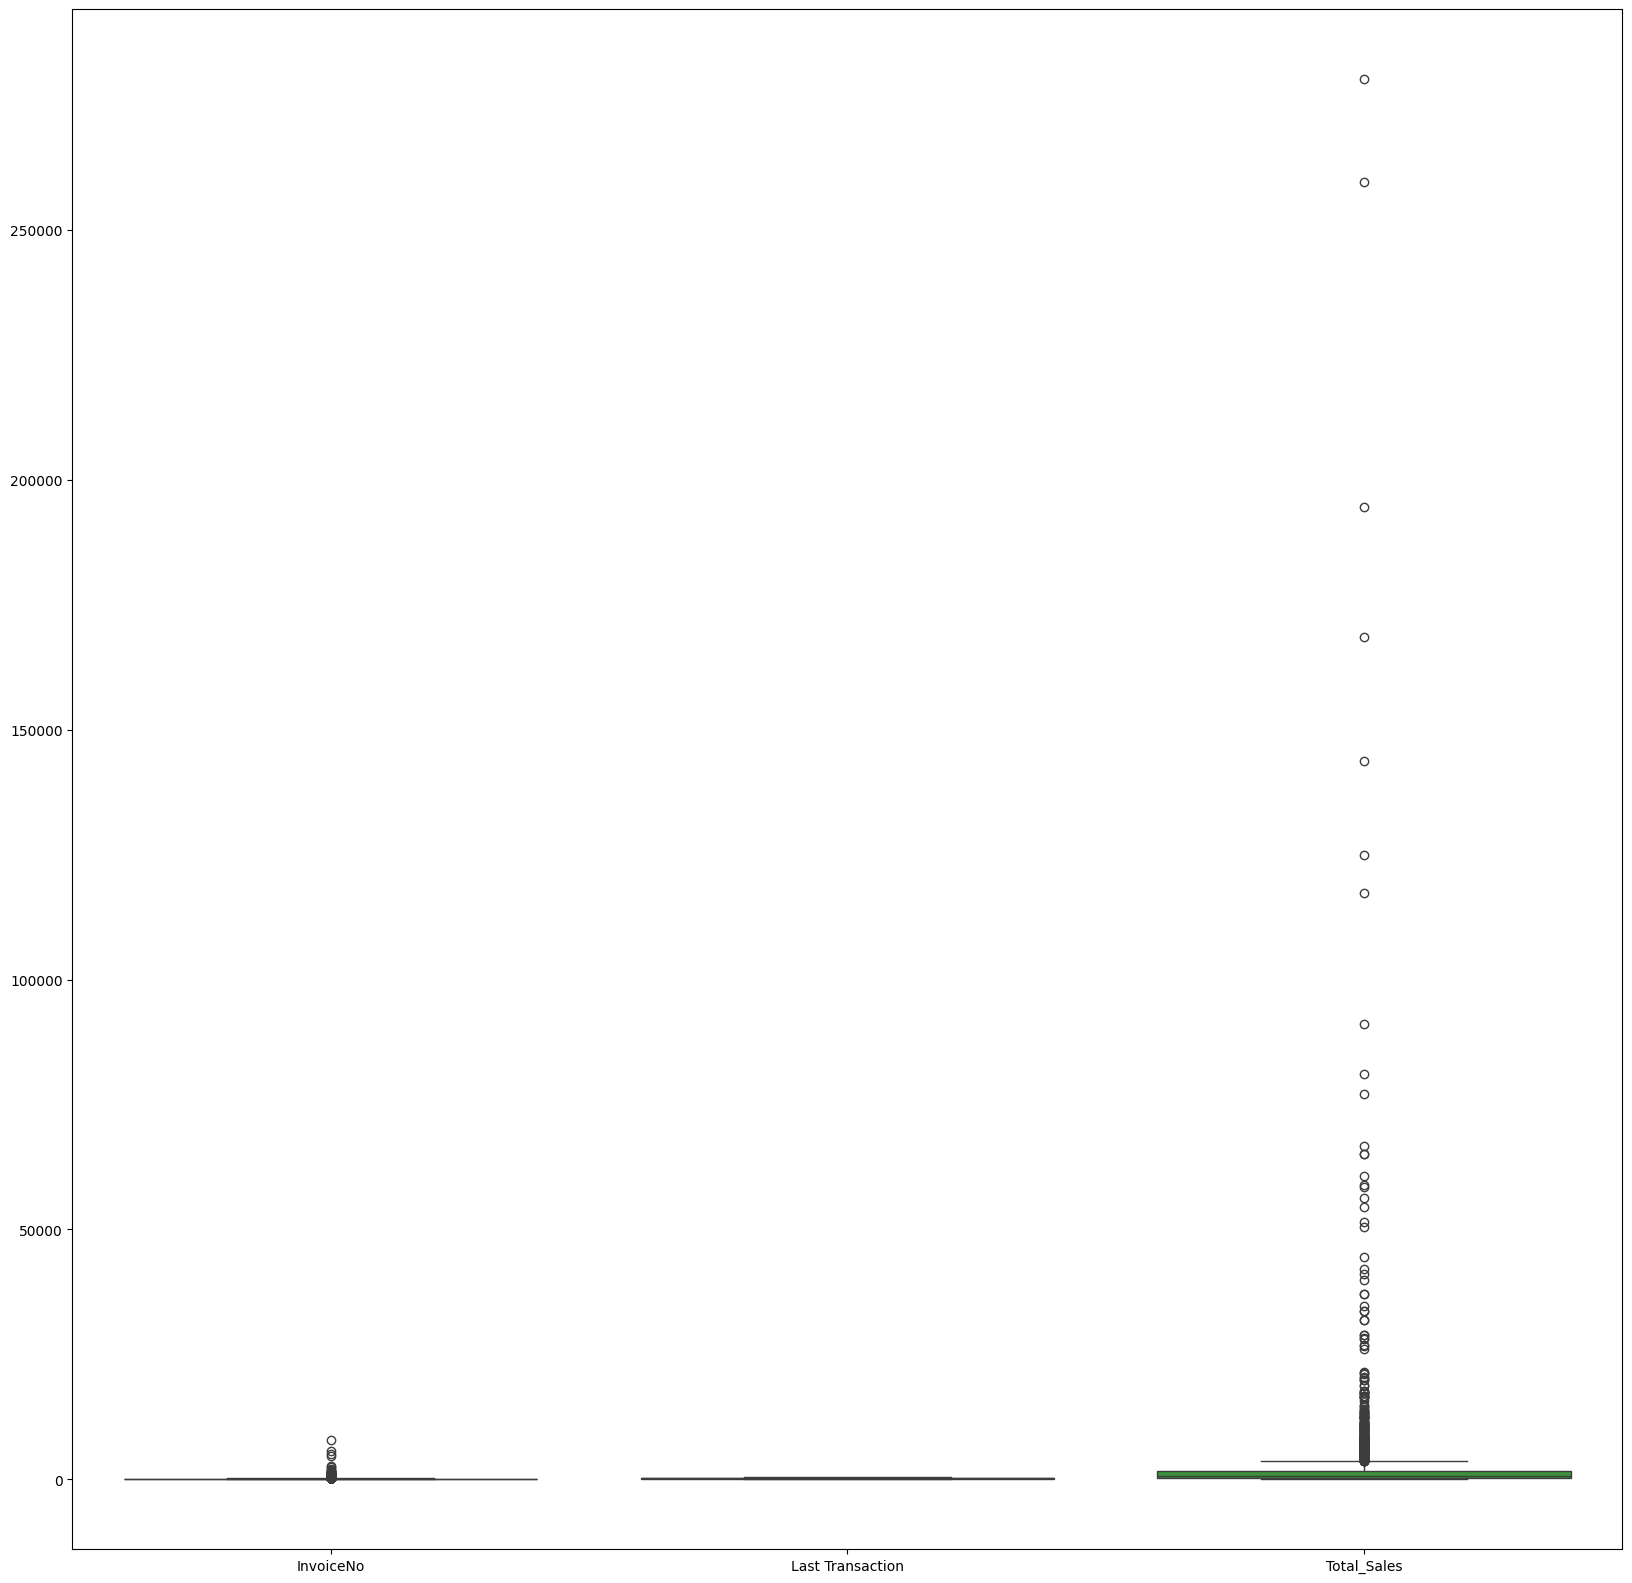

In [30]:
plt.figure(figsize=(20,20))
sns.boxplot(data=new_df[['InvoiceNo', 'Last Transaction', 'Total_Sales']])
plt.show()

In [31]:
new_df

,CustomerID,Country,Last Transaction,InvoiceNo,Total_Sales
0,12346.0,United Kingdom,325,1,77183.60
1,12347.0,Iceland,366,182,4310.00
2,12348.0,Finland,357,31,1797.24
3,12349.0,Italy,18,73,1757.55
4,12350.0,Norway,309,17,334.40
...,...,...,...,...,...
4342,18280.0,United Kingdom,277,10,180.60
4343,18281.0,United Kingdom,180,7,80.82
4344,18282.0,United Kingdom,125,12,178.05
4345,18283.0,United Kingdom,336,756,2094.88


In [32]:
IQR=new_df['Total_Sales'].quantile(0.75)-new_df['Total_Sales'].quantile(0.25)
lower_limit=new_df['Total_Sales'].quantile(0.25)-1.5*IQR
upper_limit=new_df['Total_Sales'].quantile(0.25)+1.5*IQR
new_df_iqr=new_df[(new_df['Total_Sales']<upper_limit) & (new_df['Total_Sales']>lower_limit)]
new_df_iqr.shape

(3590, 5)

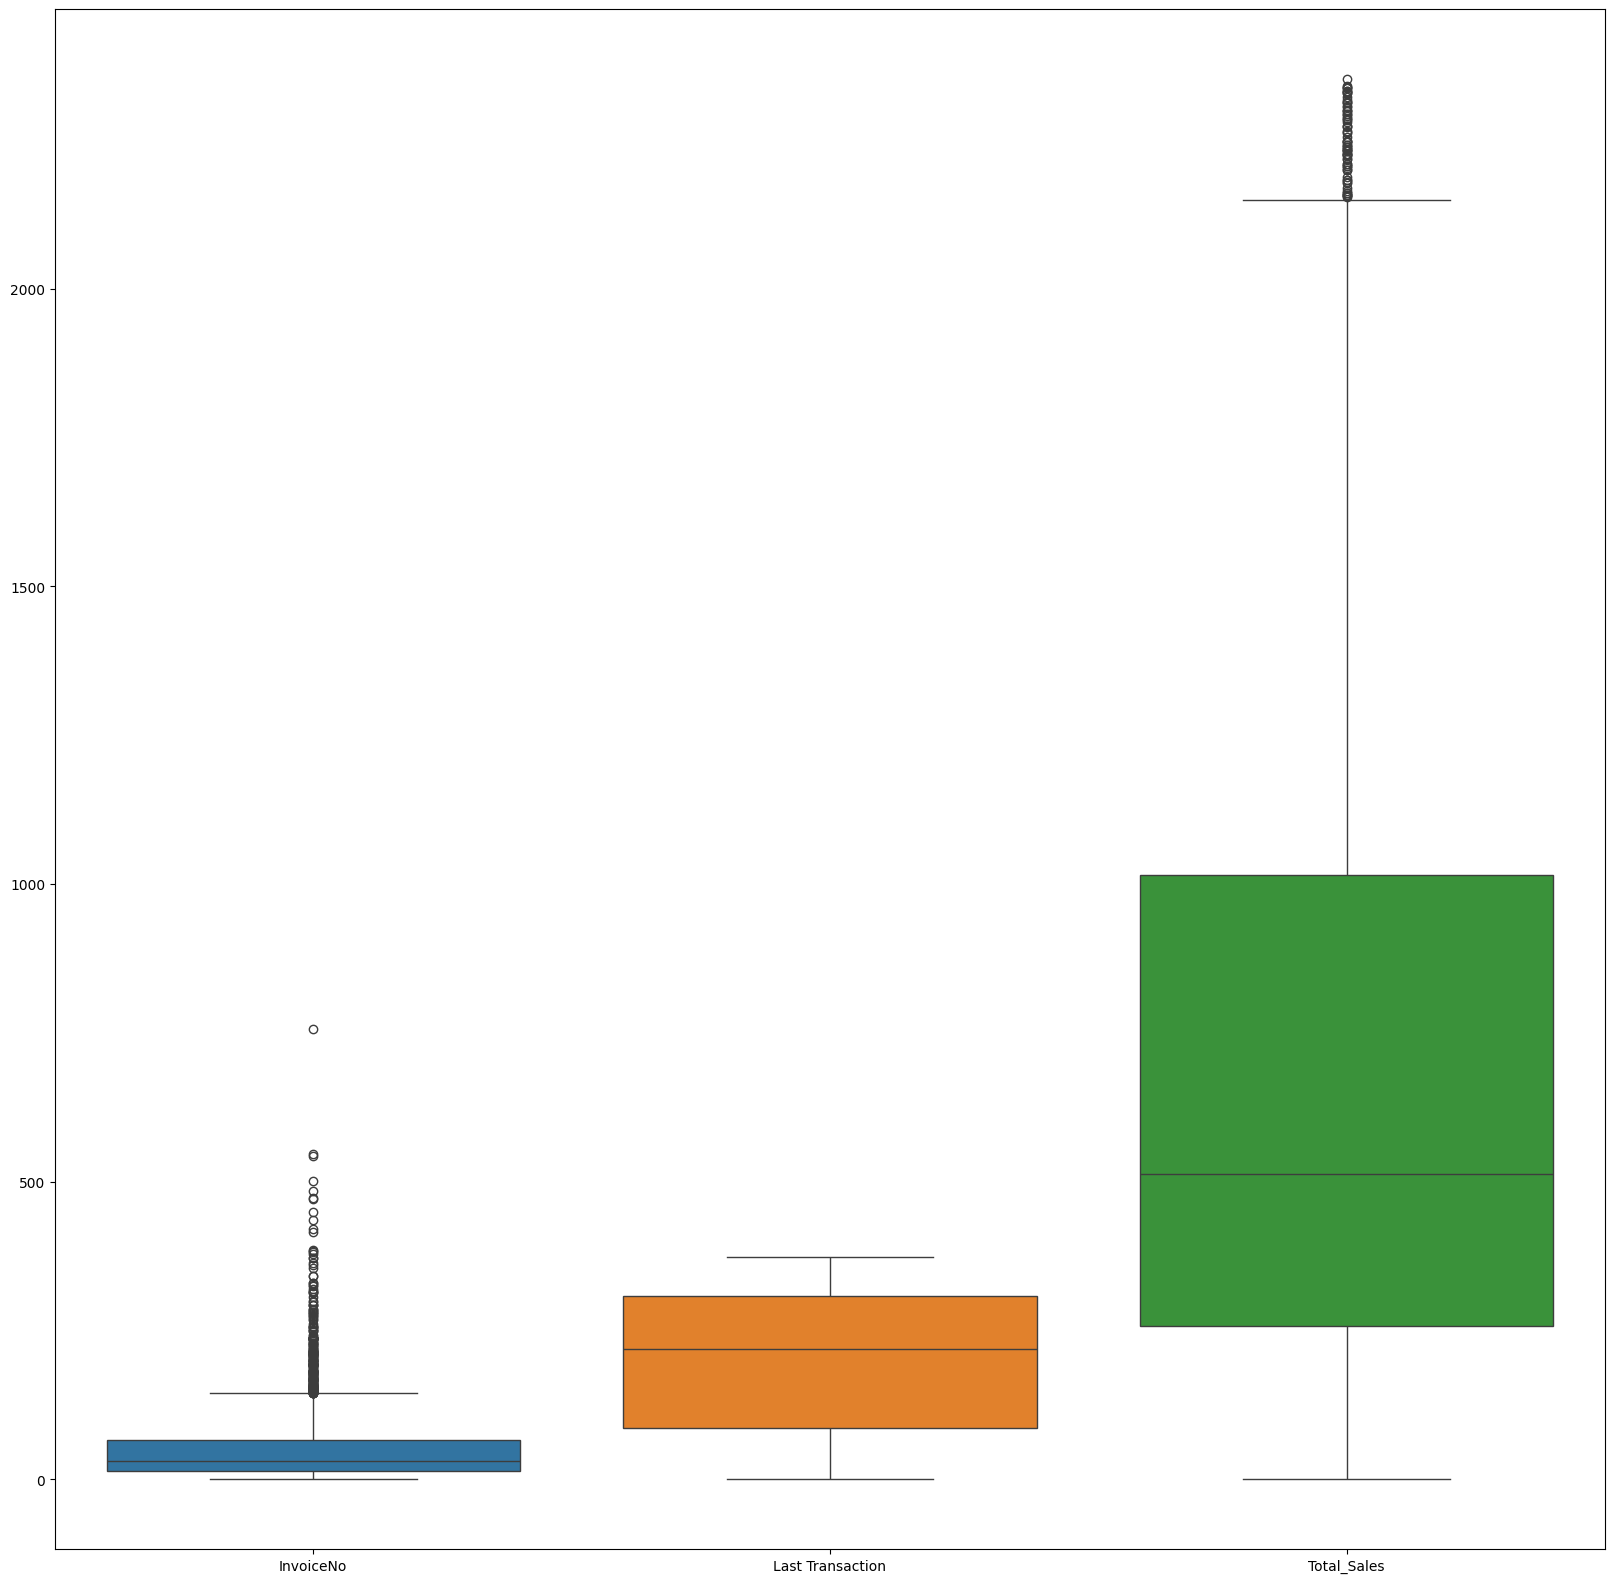

In [34]:
plt.figure(figsize=(20,20))
sns.boxplot(data=new_df_iqr[['InvoiceNo', 'Last Transaction', 'Total_Sales']])
plt.show()

In [35]:
new_df_iqr.reset_index(drop=True, inplace=True)
new_df_iqr

,CustomerID,Country,Last Transaction,InvoiceNo,Total_Sales
0,12348.0,Finland,357,31,1797.24
1,12349.0,Italy,18,73,1757.55
2,12350.0,Norway,309,17,334.40
3,12353.0,Bahrain,203,4,89.00
4,12354.0,Spain,231,58,1079.40
...,...,...,...,...,...
3585,18280.0,United Kingdom,277,10,180.60
3586,18281.0,United Kingdom,180,7,80.82
3587,18282.0,United Kingdom,125,12,178.05
3588,18283.0,United Kingdom,336,756,2094.88


## normalization of dataset using minmax scaler

In [36]:
from sklearn.preprocessing import MinMaxScaler

In [38]:
new2_df=new_df_iqr[['Last Transaction', 'InvoiceNo', 'Total_Sales']]
scaler=MinMaxScaler()
scaled_df=scaler.fit_transform(new2_df)
scaled_df=pd.DataFrame(scaled_df)
scaled_df.columns=['Last Transaction','InvoiceNo', 'TotalAmount']
scaled_df['Country']=new_df_iqr['Country']
scaled_df

,Last Transaction,InvoiceNo,TotalAmount,Country
0,0.957105,0.039735,0.763961,Finland
1,0.048257,0.095364,0.747089,Italy
2,0.828418,0.021192,0.142145,Norway
3,0.544236,0.003974,0.037832,Bahrain
4,0.619303,0.075497,0.458825,Spain
...,...,...,...,...
3585,0.742627,0.011921,0.076768,United Kingdom
3586,0.482574,0.007947,0.034355,United Kingdom
3587,0.335121,0.014570,0.075684,United Kingdom
3588,0.900804,1.000000,0.890480,United Kingdom


## KMeans clustering plot the graph using elbow method

In [40]:
pip install yellowbrick

  Obtaining dependency information for yellowbrick from https://files.pythonhosted.org/packages/06/35/c7d44bb541c06bc41b3239b27af79ea0ecc7dbb156ee1335576f99c58b91/yellowbrick-1.5-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/282.6 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/282.6 kB ? eta -:--:--
   ------------- -------------------------- 92.2/282.6 kB 1.3 MB/s eta 0:00:01
   ------------------------ --------------- 174.1/282.6 kB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 225.3/282.6 kB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 225.3/282.6 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------  276.5/282.6 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 282.6/282.6 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


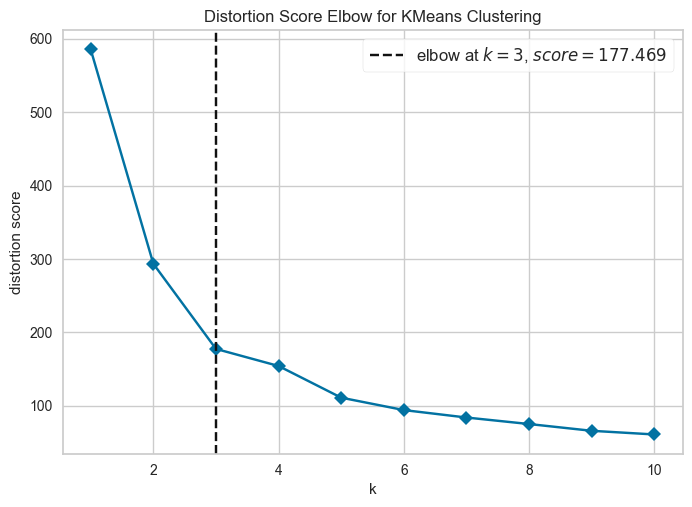

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [41]:
df_k=scaled_df.drop(columns=['Country'],axis=1)
# elbow method for kmeans
# import elbowvisualizer
from yellowbrick.cluster import KElbowVisualizer
model=KMeans()
# k is range of number of clusters
visualizer=KElbowVisualizer(model, k=(1,11), timings=False)
visualizer.fit(df_k) # fit data to visualizer
visualizer.show()

In [42]:
km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(df_k)
df_k['clusters']=y_predicted
df_k

,Last Transaction,InvoiceNo,TotalAmount,clusters
0,0.957105,0.039735,0.763961,2
1,0.048257,0.095364,0.747089,0
2,0.828418,0.021192,0.142145,1
3,0.544236,0.003974,0.037832,1
4,0.619303,0.075497,0.458825,2
...,...,...,...,...
3585,0.742627,0.011921,0.076768,1
3586,0.482574,0.007947,0.034355,0
3587,0.335121,0.014570,0.075684,0
3588,0.900804,1.000000,0.890480,2


In [44]:
from sklearn.metrics import silhouette_samples, silhouette_score
score=silhouette_score(df_k,km.labels_, metric='euclidean')  #km.labels_ is the cluster column itself
print(score)

0.760625154558778


## Hierarchical clustering

In [46]:
from sklearn.cluster import AgglomerativeClustering
hierarchical=AgglomerativeClustering(n_clusters=3)

In [47]:
y_predicted_hierarchical=hierarchical.fit_predict(df_k)
df_k['cluster_hierarchical']=y_predicted_hierarchical
df_k.head(30)

,Last Transaction,InvoiceNo,TotalAmount,clusters,cluster_hierarchical
0,0.957105,0.039735,0.763961,2,2
1,0.048257,0.095364,0.747089,0,1
2,0.828418,0.021192,0.142145,1,0
3,0.544236,0.003974,0.037832,1,0
4,0.619303,0.075497,0.458825,2,2
5,0.571046,0.015894,0.195279,1,0
6,0.402145,0.023841,0.496512,0,1
7,0.766756,0.011921,0.080722,1,0
8,0.646113,0.029139,0.234641,1,0
9,0.297587,0.111258,0.558165,0,1


In [48]:
import random as pyrandom
from scipy.spatial.distance import cdist
figsize(6,6)

NameError: name 'figsize' is not defined

In [49]:
ccolors=['go','ro','bo','mo','co','yo']
def plotclusters(data, centers=None):
    xlim([0,100]) ylim([0,100])
    if centers is None:
        plot(data[:,0], data[:,1], 'bo',markersize=5)
    else:
        for i in range(amax(centers)+1):
            plot(data[centers==i, 0], data[centers==i, 1], ccolors[i%len(ccolors)], markersize=5)
            

SyntaxError: invalid syntax (3219222653.py, line 3)

In [50]:
data=r_[4*randn(10,2)+array([70,50]),
4*randn(10,2)+array([30,50])]

plotclusters(data)

NameError: name 'r_' is not defined

In [51]:
from scipy.spatial.distance import cdist
ds=cdist(data,data)

MemoryError: Unable to allocate 1.15 TiB for an array with shape (397924, 397924) and data type object

In [52]:
from scipy.cluster.hierarchy import *
lm=linkage(ds,"single")
lm

NameError: name 'ds' is not defined

In [ ]:
_=dendogram(lm)

## DBSCAN

In [53]:
from sklearn.cluster import DBSCAN

In [54]:
dbscan=DBSCAN(eps=0.2, min_samples=4)
y_predicted_dbscan=dbscan.fit_predict(df_k)
df_k['clusters_dbscan']=y_predicted_dbscan
df_k

,Last Transaction,InvoiceNo,TotalAmount,clusters,cluster_hierarchical,clusters_dbscan
0,0.957105,0.039735,0.763961,2,2,0
1,0.048257,0.095364,0.747089,0,1,1
2,0.828418,0.021192,0.142145,1,0,2
3,0.544236,0.003974,0.037832,1,0,2
4,0.619303,0.075497,0.458825,2,2,0
...,...,...,...,...,...,...
3585,0.742627,0.011921,0.076768,1,0,2
3586,0.482574,0.007947,0.034355,0,1,1
3587,0.335121,0.014570,0.075684,0,1,1
3588,0.900804,1.000000,0.890480,2,2,-1


In [55]:
from sklearn.metrics import silhouette_samples, silhouette_score
score_dbscan=silhouette_score(df_k,dbscan.labels_, metric='euclidean')  #km.labels_ is the cluster column itself
print(score_dbscan)

0.8470393571178677
